In [614]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

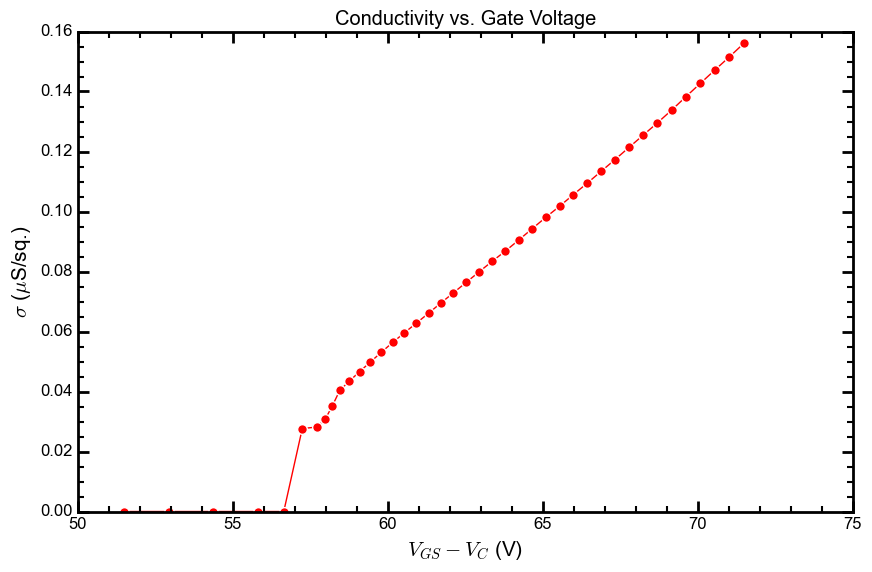

In [615]:
data = np.loadtxt("./Data-20261006/33.dat")

V_GS = data[:, 0]
I_DS = data[:, 1]
V_DS = data[:, 2]
V_C = 0.5 * (data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = -data[:, 7]
V_del = -(V_GS - V_C)

plt.plot(
    V_del,
    sigma * 1e6,
    color='red',
    marker='o',
    markevery=1,
    ls='-',
    markeredgecolor="white", markeredgewidth=1, markersize=7
    )

plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
plt.title("Conductivity vs. Gate Voltage")
plt.show()

C = 1.8e-9
A = 32e-6
Ci = C / A

Mobility (μ): 1.58 cm^2/Vs
Threshold Voltage (V_T): 54.08 V


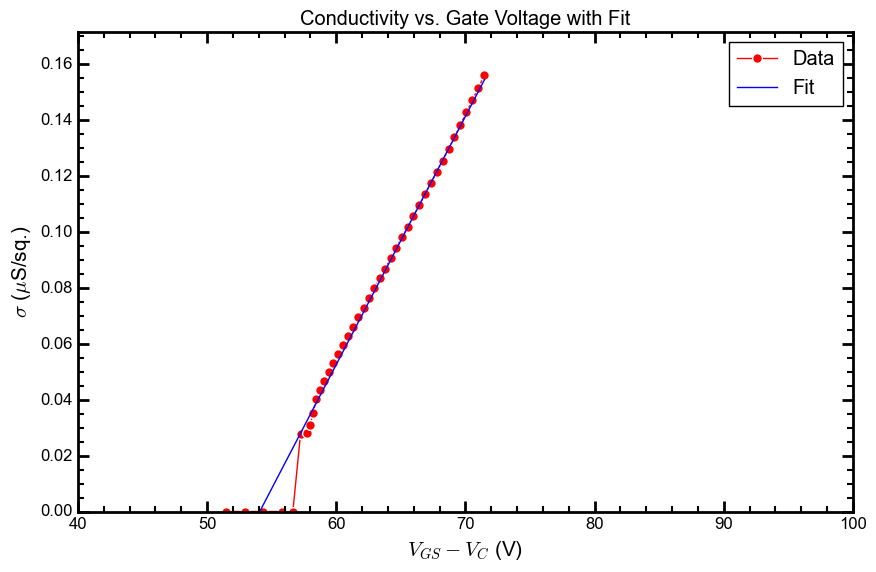

In [616]:
def func(x, a, b):
    return a*x + b

mask = (V_del > 65) & (V_del < 70)


popt, pcov = curve_fit(func, V_del[mask], sigma[mask])
sigma_fit = func(V_del, *popt)
a = popt[0]
b = popt[1]

mu = a / Ci * 1e4
V_T = -b / a

print(f"Mobility (μ): {mu:.2f} cm^2/Vs")
print(f"Threshold Voltage (V_T): {V_T:.2f} V")



# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))

plt.plot(
    V_del,
    sigma * 1e6,
    color='red',
    marker='o',
    markevery=1,
    ls='-',
    label='Data',
    markeredgecolor="white", markeredgewidth=1, markersize=7
    )
plt.plot(
    V_del,
    sigma_fit * 1e6,
    color='blue',
    ls='-',
    label=f'Fit'
    )
plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
plt.title("Conductivity vs. Gate Voltage with Fit")
plt.xlim(40,100)
plt.ylim(0, sigma.max() * 1e6 * 1.1)  # Convert to μS/sq. for y-axis limits
plt.legend(numpoints=1)
plt.show()




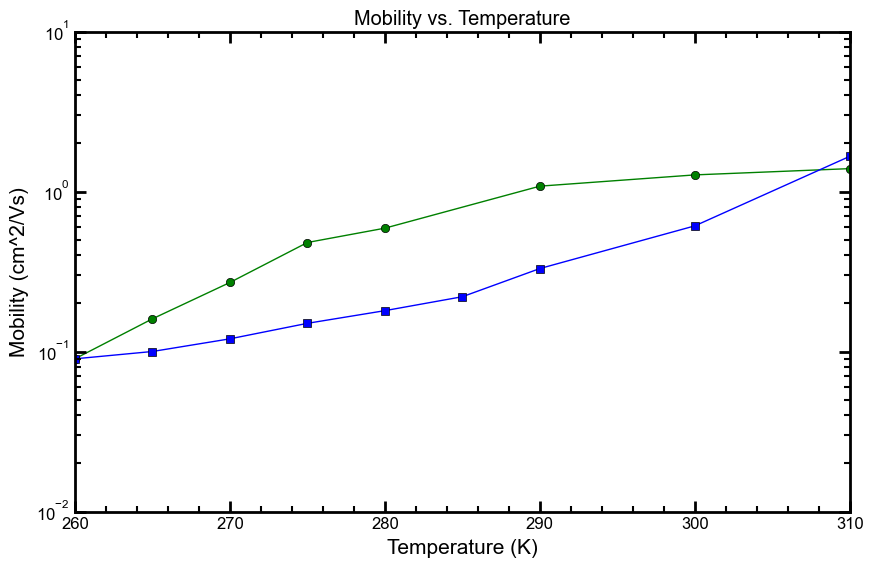

In [617]:
T_1 = [310,300,290,280,275,270,265,260]
mu_1 = [1.39,1.27,1.08,0.59,0.48,0.27,0.16,0.09]

T_2 = [260, 265, 270, 275, 280, 285, 290, 300, 310]
mu_2 = [0.09, 0.10, 0.12, 0.15, 0.18, 0.22, 0.33, 0.61, 1.66]

plt.semilogy(T_1, mu_1, marker='o', linestyle='-', color='green')
plt.semilogy(T_2, mu_2, marker='s', linestyle='-', color='blue')
plt.xlabel('Temperature (K)')
plt.ylabel('Mobility (cm^2/Vs)')
plt.title('Mobility vs. Temperature')
plt.show()


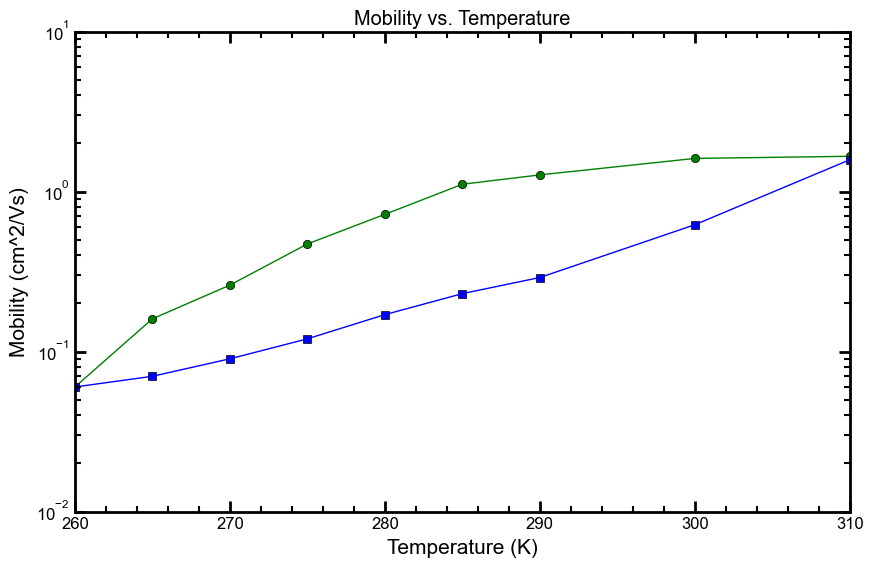

In [618]:
T_1 = [310,300,290, 285,280,275,270,265,260]
mu_1 = [1.66,1.61,1.27,1.11,0.72,0.47,0.26,0.16, 0.06]

T_2 = [260, 265, 270, 275, 280, 285, 290, 300, 310]
mu_2 = [0.06, 0.07, 0.09, 0.12, 0.17, 0.23, 0.29, 0.62, 1.58]

plt.semilogy(T_1, mu_1, marker='o', linestyle='-', color='green')
plt.semilogy(T_2, mu_2, marker='s', linestyle='-', color='blue')
plt.xlabel('Temperature (K)')
plt.ylabel('Mobility (cm^2/Vs)')
plt.title('Mobility vs. Temperature')
plt.show()